### [Scatter Regression Analysis Plots with Edge Histograms using **Matplotlib** and **Statsmodels**](https://medium.com/top-python-libraries/create-cool-scatter-regression-analysis-plots-with-edge-histograms-using-matplotlib-and-statsmodels-5201ddf7c446)

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.model_selection import train_test_split

from scipy.stats import linregress

import sys
if "google.colab" not in sys.modules:
  import matplotlib
  matplotlib.use('TkAgg')
else:
  %matplotlib inline

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

##### **Generate sample data and partitions**

In [2]:
# 1. Generate Sample Data
np.random.seed(0) # Set the seed for the random number generator to ensure the same sequence of random numbers every time, facilitating reproducibility
true_data_full = np.linspace(10, 50, 370) # Generate an arithmetic sequence from 10 to 50 with 370 points to serve as the ground truth X data

# Generate predicted Y data based on ground truth X: Y = 0.86 * X + 3.454 + noise
# Noise follows a normal distribution with a mean of 0 and a standard deviation of 2, matching the shape of true_data_full
predict_data_full = 0.86 * true_data_full + 3.454 + np.random.normal(0, 2, size=true_data_full.shape)

# 2. Data Splitting
# Split the full ground truth and predicted data into training and validation sets
# test_size=0.3 indicates that the validation set accounts for 30% of the total data
# random_state=42 ensures the splitting result is consistent across different runs
true_train, true_val, predict_train, predict_val = train_test_split(
    true_data_full, predict_data_full, test_size=0.3, random_state=42
)

##### **Define drawing parameters**

In [3]:
# --- Define Parameters ---
x_min_limit = 5  # Set the minimum display limit for the X-axis
x_max_limit = 55 # Set the maximum display limit for the X-axis
y_min_limit = 5  # Set the minimum display limit for the Y-axis
y_max_limit = 55 # Set the maximum display limit for the Y-axis

main_axis_label_fontsize = 16 # Define font size for main plot axis labels (e.g., "True Data", "Predicted Data")
hist_axis_label_fontsize = 14 # Define font size for marginal histogram axis labels ("Frequency")
main_tick_label_fontsize = 12 # Define font size for all axis tick numerical labels

# Tick and axis parameters for the main plot
spine_linewidth = 1.5  # Define uniform thickness for main plot axis spines and tick lines
major_tick_length = 6  # Define length of major ticks in the main plot
minor_tick_length = 3  # Define length of minor ticks in the main plot

# Marginal histogram tick parameters (these allow independent control over the style of marginal plots)
hist_major_tick_direction = 'out' # Define direction for marginal histogram major ticks ('out' means pointing outward)
hist_major_tick_length_val = 4.0  # Define length for marginal histogram major ticks (adjustable)
hist_major_tick_width_val = 1.2   # Define thickness for marginal histogram major ticks (adjustable)

hist_minor_tick_direction = 'out' # Define direction for marginal histogram minor ticks
hist_minor_tick_length_val = 2.0  # Define length for marginal histogram minor ticks (adjustable)
hist_minor_tick_width_val = 1.0   # Define thickness for marginal histogram minor ticks (adjustable)

# Size ratio control parameters for marginal histograms relative to the main plot
#
main_plot_width_ratio = 4    # Define width ratio factor for the main scatter plot in the GridSpec layout
hist_y_width_ratio = 0.8     # Define width ratio factor for the right-side histogram in the GridSpec layout
main_plot_height_ratio = 4   # Define height ratio factor for the main scatter plot in the GridSpec layout
hist_x_height_ratio = 0.8    # Define height ratio factor for the top histogram in the GridSpec layout

##### **Linear fitting and confidence interval calculation**

In [4]:
# --- Linear Fitting ---
# Perform linear regression analysis on the training data
# linregress returns: slope, intercept, r-value, p-value, and the standard error of the slope
slope_train, intercept_train, r_value_train, _, _ = linregress(true_train, predict_train)

# Add a constant term (intercept) to the independent variable X for the training set, required for OLS model fitting
X_ols_train = sm.add_constant(true_train)
# Fit the model using Ordinary Least Squares (OLS) for the training data
model_ols_train = sm.OLS(predict_train, X_ols_train).fit()

# Generate a sequence of X values (100 points) to plot the training set's regression line
line_x_fit_train = np.linspace(true_train.min(), true_train.max(), 100)
X_fit_ols_train = sm.add_constant(line_x_fit_train) # Add constant term for the fit line X values

# Obtain prediction results for the training fit line, including confidence interval data
predictions_ols_train = model_ols_train.get_prediction(X_fit_ols_train)
# Get a summary frame of the predictions; alpha=0.05 calculates the 95% confidence interval
summary_frame_train = predictions_ols_train.summary_frame(alpha=0.05)

line_y_fit_train = summary_frame_train['mean']          # Extract the mean Y values (predicted values) for the fit line
ci_lower_train = summary_frame_train['mean_ci_lower']    # Extract the lower bound of the 95% confidence interval
ci_upper_train = summary_frame_train['mean_ci_upper']    # Extract the upper bound of the 95% confidence interval

# Perform linear regression analysis on the validation data (similar process to the training set)
slope_val, intercept_val, r_value_val, _, _ = linregress(true_val, predict_val)
X_ols_val = sm.add_constant(true_val) # Add constant term for validation set X
model_ols_val = sm.OLS(predict_val, X_ols_val).fit() # Fit OLS model for validation data

# Handle edge cases where validation set has only one point or identical X values, which would break linspace
if true_val.min() == true_val.max():
    line_x_fit_val = np.array([true_val.min()]) # If X values are identical, the range is just that single value
else: # Normal case
    line_x_fit_val = np.linspace(true_val.min(), true_val.max(), 100) # Generate X sequence for validation fit line

X_fit_ols_val = sm.add_constant(line_x_fit_val) # Add constant term for the fit line X values
predictions_ols_val = model_ols_val.get_prediction(X_fit_ols_val) # Get prediction results for validation fit line
summary_frame_val = predictions_ols_val.summary_frame(alpha=0.05) # Get summary frame with 95% CI

line_y_fit_val = summary_frame_val['mean']        # Extract mean predicted Y values for validation
ci_lower_val = summary_frame_val['mean_ci_lower']  # Extract lower CI bound for validation
ci_upper_val = summary_frame_val['mean_ci_upper']  # Extract upper CI bound for validation

##### **Calculate statistical indicators**

In [5]:
# Calculate Statistical Metrics
# Calculate the R-squared value (Coefficient of Determination) for the training set
r2_train_fit = r_value_train ** 2
# Calculate the Root Mean Square Error (RMSE) for the training set
# RMSE measures the average magnitude of the error by squaring the differences
rmse_train_fit = np.sqrt(np.mean((predict_train - (slope_train * true_train + intercept_train))**2))
# Calculate the Mean Absolute Error (MAE) for the training set
# MAE is the average of the absolute differences between predicted and actual values
mae_train_fit = np.mean(np.abs(predict_train - (slope_train * true_train + intercept_train)))

# Calculate statistical metrics for the validation set (same logic as above)
r2_val_fit = r_value_val ** 2
rmse_val_fit = np.sqrt(np.mean((predict_val - (slope_val * true_val + intercept_val))**2))
mae_val_fit = np.mean(np.abs(predict_val - (slope_val * true_val + intercept_val)))

##### **Define colors and create canvas and subgraph layouts**

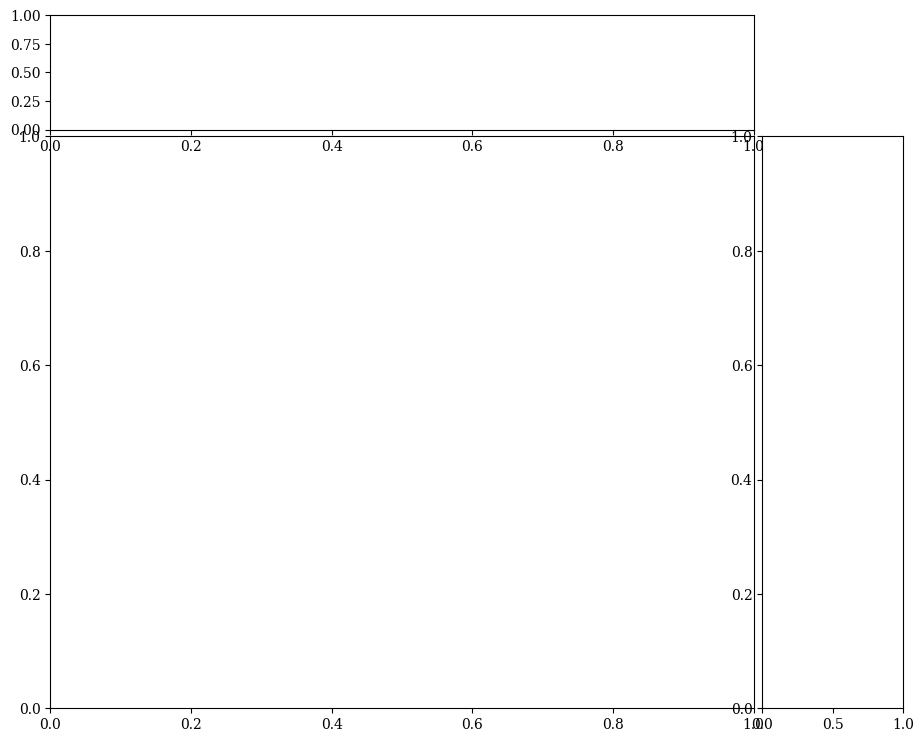

In [6]:
# Define color variables
bright_blue = '#0000FF' # Define bright blue (used for training data)
bright_red = '#FF0000'  # Define bright red (used for validation data)
train_fit_color = 'gray'      # Define the color for the training set fit line as gray
val_fit_color = '#FF8C00'     # Define the color for the validation set fit line as deep orange

# --- Plotting ---
fig = plt.figure(figsize=(11, 9)) # Create a new figure object and set its dimensions to 11x9 inches

# Create a subplot layout using GridSpec: 2 rows and 2 columns, with relative width and height ratios
# width_ratios and height_ratios control the relative size of each column and row
# wspace and hspace control the horizontal and vertical spacing between subplots
gs = fig.add_gridspec(nrows=2, ncols=2,
                      width_ratios=[main_plot_width_ratio, hist_y_width_ratio],
                      height_ratios=[hist_x_height_ratio, main_plot_height_ratio],
                      wspace=0.02, hspace=0.02)
#

ax_scatter = fig.add_subplot(gs[1, 0]) # Create the main scatter plot in the 2nd row, 1st column
ax_hist_x = fig.add_subplot(gs[0, 0], sharex=ax_scatter) # Create the top histogram (1st row, 1st column) and link its X-axis to the scatter plot
ax_hist_y = fig.add_subplot(gs[1, 1], sharey=ax_scatter) # Create the right histogram (2nd row, 2nd column) and link its Y-axis to the scatter plot

ax_empty_top_right = fig.add_subplot(gs[0, 1]) # Create a subplot in the 1st row, 2nd column as an empty placeholder
ax_empty_top_right.set_visible(False) # Set the top-right placeholder to invisible

##### **Main scatter plot + histogram**

In [7]:
# --- Main Scatter Plot ---
# Plot training data scatter points
ax_scatter.scatter(true_train, predict_train, color=bright_blue, s=20, alpha=1, label='Training Data')
# Plot validation data scatter points
ax_scatter.scatter(true_val, predict_val, color=bright_red, s=20, alpha=1, label='Validation Data')

# Plot the linear regression line for the training set (solid line)
ax_scatter.plot(line_x_fit_train, line_y_fit_train, color=train_fit_color, linewidth=2, label='Fit (Train)')
# Shade the 95% Confidence Interval for the training set fit
ax_scatter.fill_between(line_x_fit_train, ci_lower_train, ci_upper_train, color=train_fit_color, alpha=0.15, label='95% CI (Train)')

# Plot the linear regression line for the validation set (dashed line)
ax_scatter.plot(line_x_fit_val, line_y_fit_val, color=val_fit_color, linewidth=2, linestyle='--', label='Fit (Val)')
# Shade the 95% Confidence Interval for the validation set fit
ax_scatter.fill_between(line_x_fit_val, ci_lower_val, ci_upper_val, color=val_fit_color, alpha=0.15, label='95% CI (Val)')

# Generate coordinate data for a 1:1 reference line (where Predicted = True)
one_to_one_line_coords = np.linspace(min(x_min_limit, y_min_limit), max(x_max_limit, y_max_limit), 100)
# Plot the 1:1 reference line (dotted line) to evaluate model bias at a glance
ax_scatter.plot(one_to_one_line_coords, one_to_one_line_coords, color='blue', linestyle=':', linewidth=1.5, label='1:1 Line')

# --- Marginal Histograms ---
num_bins = 100 # Set the number of bins (granularity) for the histograms

# Top Histogram (ax_hist_x) - Distribution of Ground Truth X Data
bins_x = np.linspace(x_min_limit, x_max_limit, num_bins + 1)
ax_hist_x.hist([true_train, true_val], bins=bins_x,
               color=[bright_blue, bright_red], # stacked=True is commented out to show overlapping/side-by-side distributions
               histtype='bar', linewidth=0, alpha=1)
ax_hist_x.set_ylim(bottom=0)
plt.setp(ax_hist_x.get_xticklabels(), visible=False) # Hide X-axis tick labels to prevent overlap with the main plot
ax_hist_x.set_ylabel('Frequency', fontsize=hist_axis_label_fontsize)

# Right Histogram (ax_hist_y) - Distribution of Predicted Y Data
bins_y = np.linspace(y_min_limit, y_max_limit, num_bins + 1)
ax_hist_y.hist([predict_train, predict_val], bins=bins_y,
               color=[bright_blue, bright_red],
               orientation='horizontal', # Set to horizontal to align with the Y-axis of the scatter plot
               histtype='bar', linewidth=0, alpha=1)
ax_hist_y.set_xlim(left=0)
plt.setp(ax_hist_y.get_yticklabels(), visible=False) # Hide Y-axis tick labels
ax_hist_y.set_xlabel('Frequency', fontsize=hist_axis_label_fontsize)

Text(0.5, 4.444444444444452, 'Frequency')

##### **Add statistics text box**

In [8]:
# --- Text Box ---
fit_info_text = (
    f'N (Total) = {len(true_data_full)}\n'
    # ... (Inner f-string content remains consistent with your original data) ...
    f'  RMSE = {rmse_val_fit:.3f}; MAE = {mae_val_fit:.3f}'
)

# Place the statistical information on the main scatter plot
ax_scatter.text(0.03, 0.97, fit_info_text,
                fontsize=10,
                verticalalignment='top',         # Align the top edge of the text with the Y coordinate
                transform=ax_scatter.transAxes,    # Use axis coordinates (0 to 1) instead of data coordinates
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85)) # Create a rounded white background box with 85% opacity

Text(0.03, 0.97, 'N (Total) = 370\n  RMSE = 2.188; MAE = 1.729')

##### **Adjust the main image style**

In [9]:
# --- Main Plot Style ---
# Set the label for the X-axis and Y-axis using the predefined font size
ax_scatter.set_xlabel('True Data', fontsize=main_axis_label_fontsize)
ax_scatter.set_ylabel('Predicted Data', fontsize=main_axis_label_fontsize)

# Place the legend in the lower-right corner
ax_scatter.legend(loc='lower right', fontsize=10)

# Enable the grid with a dashed line style and 50% transparency for better readability
ax_scatter.grid(True, linestyle='--', alpha=0.5)

# Apply the previously defined axis limits
ax_scatter.set_xlim(x_min_limit, x_max_limit)
ax_scatter.set_ylim(y_min_limit, y_max_limit)

# Define the interval for major ticks (every 10 units)
major_tick_interval_main = 10
# Use MultipleLocator to automatically set ticks at the specified interval
ax_scatter.xaxis.set_major_locator(ticker.MultipleLocator(major_tick_interval_main))

# ... (Additional X/Y major and minor locator settings would go here) ...

# Set tick parameters: 'direction=in' makes the tick marks point inside the plot box
ax_scatter.tick_params(axis='both', which='major', direction='in', labelsize=main_tick_label_fontsize, length=major_tick_length, width=spine_linewidth)
ax_scatter.tick_params(axis='both', which='minor', direction='in', length=minor_tick_length, width=spine_linewidth)

# ... (Additional tick styling settings would go here) ...

# Loop through the major tick labels on both axes to make them bold for a more professional look
for label in ax_scatter.get_xticklabels(which='major'):
    label.set_fontweight('bold')
for label in ax_scatter.get_yticklabels(which='major'):
    label.set_fontweight('bold')

# Set the thickness of the four plot borders (spines) to ensure the frame stands out
for spine in ax_scatter.spines.values():
    spine.set_linewidth(spine_linewidth)

##### **Save and display**

In [10]:
if "google.colab" not in sys.modules:
  plt.savefig('linear_fit_custom_hist_ticks_english.png', dpi=720)
plt.show()